In [1]:
from pathlib import Path

In [2]:
path = Path("./../dl/2/IMDB Dataset.csv")

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(path)
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [5]:
df.isna().sum()

review       0
sentiment    0
dtype: int64

In [6]:
df["label"] = df.sentiment.map({"negative" : 0, "positive" : 1})
x = df.review
y = df.label

In [7]:
x

0        One of the other reviewers has mentioned that ...
1        A wonderful little production. <br /><br />The...
2        I thought this was a wonderful way to spend ti...
3        Basically there's a family where a little boy ...
4        Petter Mattei's "Love in the Time of Money" is...
                               ...                        
49995    I thought this movie did a down right good job...
49996    Bad plot, bad dialogue, bad acting, idiotic di...
49997    I am a Catholic taught in parochial elementary...
49998    I'm going to have to disagree with the previou...
49999    No one expects the Star Trek movies to be high...
Name: review, Length: 50000, dtype: str

In [8]:
y

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: label, Length: 50000, dtype: int64

In [9]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [10]:
from tensorflow.keras import Sequential, layers

vectorizer = layers.TextVectorization(
    max_tokens=10000,
    output_mode="int",
    output_sequence_length=200
)

In [11]:
import tensorflow as tf

In [12]:
text_ds = tf.data.Dataset.from_tensor_slices(x_train).batch(256)

In [13]:
vectorizer.adapt(text_ds)

In [14]:
model = Sequential([
    layers.Input(shape=(1,), dtype=tf.string),
    vectorizer,
    layers.Embedding(input_dim=10000, output_dim=64),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1)
])    

In [15]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["accuracy"]
)

In [16]:
x_train = x_train.astype(str).to_numpy()
x_test = x_test.astype(str).to_numpy()

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=128
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.6921 - loss: 0.1995 - val_accuracy: 0.8396 - val_loss: 0.1263
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8573 - loss: 0.1131 - val_accuracy: 0.8676 - val_loss: 0.1045
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8864 - loss: 0.0962 - val_accuracy: 0.8621 - val_loss: 0.1055
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9041 - loss: 0.0848 - val_accuracy: 0.8694 - val_loss: 0.0991
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9128 - loss: 0.0790 - val_accuracy: 0.8546 - val_loss: 0.1057
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9194 - loss: 0.0739 - val_accuracy: 0.8597 - val_loss: 0.1028
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9247 - loss: 0.0708 - val_accuracy: 0.8643 - val_loss: 0.1008
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9308 - loss: 0.0675 - val_accu

In [17]:
y_pred = model.predict(x_test).flatten()
y_pred = (y_pred >= 0.5).astype(int)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([0, 1, 0, ..., 1, 0, 1], shape=(10000,))

In [18]:
import matplotlib.pyplot as plt

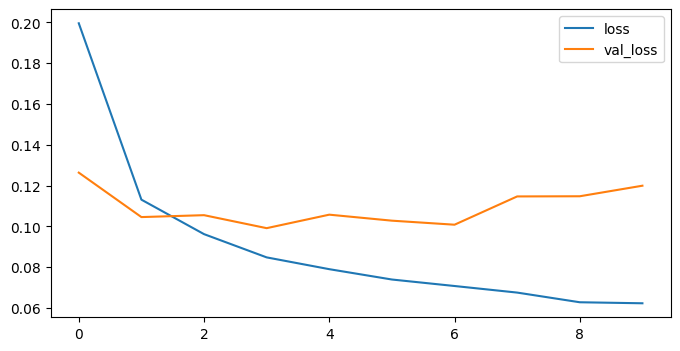

In [20]:
plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label = "loss")
plt.plot(history.history["val_loss"], label = "val_loss")
plt.legend()
plt.show()

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

In [25]:
print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))

              precision    recall  f1-score   support

    negative       0.78      0.93      0.85      4961
    positive       0.92      0.75      0.82      5039

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000



In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
dis = ConfusionMatrixDisplay(cm, display_labels= ["negative", "positive"])

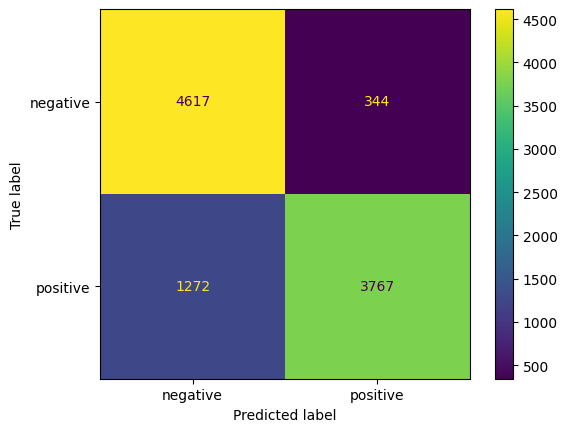

In [32]:
dis.plot()
plt.show()

In [27]:
import inspect
print(inspect.getsource(ConfusionMatrixDisplay))

class ConfusionMatrixDisplay:
    """Confusion Matrix visualization.

    It is recommended to use
    :func:`~sklearn.metrics.ConfusionMatrixDisplay.from_estimator` or
    :func:`~sklearn.metrics.ConfusionMatrixDisplay.from_predictions` to
    create a :class:`ConfusionMatrixDisplay`. All parameters are stored as
    attributes.

    For general information regarding `scikit-learn` visualization tools, see
    the :ref:`Visualization Guide <visualizations>`.
    For guidance on interpreting these plots, refer to the
    :ref:`Model Evaluation Guide <confusion_matrix>`.

    Parameters
    ----------
    confusion_matrix : ndarray of shape (n_classes, n_classes)
        Confusion matrix.

    display_labels : ndarray of shape (n_classes,), default=None
        Display labels for plot. If None, display labels are set from 0 to
        `n_classes - 1`.

    Attributes
    ----------
    im_ : matplotlib AxesImage
        Image representing the confusion matrix.

    text_ : ndarray of sh